# EfficientFireNet (2022) Training - SOTA Baseline

**FLAME Dataset Segmentation Training**

## Training Targets
- **mIoU**: > 0.75 on FLAME validation set
- **Model Size**: < 5MB
- **Training**: Adam optimizer, Dice Loss + CrossEntropy, 20% validation split

## Architecture
- EfficientNet-B0 backbone (ImageNet pretrained)
- Lightweight decoder with transpose convolutions
- Binary segmentation (fire/no-fire)

## Dataset
- Path: `data/processed/Output/Segmentation_Augmented/`
- Images: RGB .jpg files
- Masks: Binary .png files
- Split: 80% train, 20% validation

## 1. Setup and Imports

In [2]:
print(f'📅 Started: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

📅 Started: 2026-04-03 02:26:15


## 2. Training Configuration

In [3]:
# Training Configuration
CONFIG = {
    'data': {
        'root_dir': '../../data/processed/Output/Segmentation_Augmented',
        'img_size': 256,
        'batch_size': 8,  # Smaller batch for EfficientNet
        'num_workers': 2,
        'train_ratio': 0.8,  # 80% train, 20% val
    },
    'model': {
        'num_classes': 2,
        'pretrained': True,
    },
    'training': {
        'epochs': 50,
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'patience': 10,  # Early stopping
        'save_every': 10,
    },
    'loss': {
        'ce_weight': 0.5,
        'dice_weight': 0.5,
        'use_focal': True,
    },
    'output': {
        'model_dir': '../../models/trained/sota_baselines/efficientfirenet_2022',
        'best_model_path': '../../models/trained/sota_baselines/efficientfirenet_2022/best_model.pth',
        'logs_path': '../../models/trained/sota_baselines/efficientfirenet_2022/training_logs.json',
    }
}

print('📋 Training Configuration:')
print(json.dumps(CONFIG, indent=2))

# Verify data directory exists
data_path = Path(CONFIG['data']['root_dir'])
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")

print(f'✅ Data directory verified: {data_path}')

📋 Training Configuration:
{
  "data": {
    "root_dir": "../../data/processed/Output/Segmentation_Augmented",
    "img_size": 256,
    "batch_size": 8,
    "num_workers": 2,
    "train_ratio": 0.8
  },
  "model": {
    "num_classes": 2,
    "pretrained": true
  },
  "training": {
    "epochs": 50,
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "patience": 10,
    "save_every": 10
  },
  "loss": {
    "ce_weight": 0.5,
    "dice_weight": 0.5,
    "use_focal": true
  },
  "output": {
    "model_dir": "../../models/trained/sota_baselines/efficientfirenet_2022",
    "best_model_path": "../../models/trained/sota_baselines/efficientfirenet_2022/best_model.pth",
    "logs_path": "../../models/trained/sota_baselines/efficientfirenet_2022/training_logs.json"
  }
}
✅ Data directory verified: ..\..\data\processed\Output\Segmentation_Augmented


## 3. Dataset Setup

In [12]:
# Create datasets
print('📦 Creating FLAME datasets...')

train_dataset = FLAMEDataset(
    root_dir=CONFIG['data']['root_dir'],
    split='train',
    img_size=CONFIG['data']['img_size'],
    train_ratio=CONFIG['data']['train_ratio'],
    augment=True,
    seed=42
)

val_dataset = FLAMEDataset(
    root_dir=CONFIG['data']['root_dir'],
    split='val',
    img_size=CONFIG['data']['img_size'],
    train_ratio=CONFIG['data']['train_ratio'],
    augment=False,  # No augmentation for validation
    seed=42
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['data']['batch_size'],
    shuffle=True,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['data']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=torch.cuda.is_available()
)

print(f'✅ Training samples: {len(train_dataset)}')
print(f'✅ Validation samples: {len(val_dataset)}')
print(f'✅ Batch size: {CONFIG["data"]["batch_size"]}')
print(f'✅ Image size: {CONFIG["data"]["img_size"]}x{CONFIG["data"]["img_size"]}')

# Visualize a sample
sample = train_dataset[0]
print(f'✅ Sample keys: {list(sample.keys())}')
print(f'✅ Image shape: {sample["image"].shape}')
print(f'✅ Mask shape: {sample["mask"].shape}')
print(f'✅ Filename: {sample["filename"]}')

📦 Creating FLAME datasets...
FLAME Dataset (train): 646 samples, size=256x256, augment=True
FLAME Dataset (val): 162 samples, size=256x256, augment=False
✅ Training samples: 646
✅ Validation samples: 162
✅ Batch size: 8
✅ Image size: 256x256
✅ Sample keys: ['image', 'mask', 'filename']
✅ Image shape: torch.Size([3, 256, 256])
✅ Mask shape: torch.Size([1, 256, 256])
✅ Filename: image_1759_base.jpg


## 4. Model Setup

In [13]:
# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

## 5. Training Loop

In [14]:
# Training metrics storage
training_logs = {
    'config': CONFIG,
    'epochs': [],
    'train_loss': [],
    'val_loss': [],
    'train_miou': [],
    'val_miou': [],
    'train_fire_iou': [],
    'val_fire_iou': [],
    'learning_rate': [],
    'best_epoch': 0,
    'best_miou': 0.0,
}

def calculate_metrics(preds, targets):
    """Calculate mIoU and Fire IoU metrics."""
    miou = calculate_miou(preds, targets, num_classes=2)
    fire_iou = calculate_fire_iou(preds, targets)
    return miou, fire_iou

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    epoch_loss = 0.0
    all_preds = []
    all_targets = []

    for batch in tqdm(loader, desc='Training'):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device).long()

        optimizer.zero_grad()

        outputs = model(images)
        loss_dict = criterion(outputs, masks.squeeze(1))
        loss = loss_dict['total']

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Store predictions for metrics
        preds = outputs.detach().cpu()
        targets = masks.squeeze(1).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

    # Calculate epoch metrics
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    miou, fire_iou = calculate_metrics(all_preds, all_targets)

    return epoch_loss / len(loader), miou, fire_iou

def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    epoch_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Validating'):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device).long()

            outputs = model(images)
            loss_dict = criterion(outputs, masks.squeeze(1))
            loss = loss_dict['total']

            epoch_loss += loss.item()

            # Store predictions for metrics
            preds = outputs.cpu()
            targets = masks.squeeze(1).cpu()
            all_preds.append(preds)
            all_targets.append(targets)

    # Calculate epoch metrics
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    miou, fire_iou = calculate_metrics(all_preds, all_targets)

    return epoch_loss / len(loader), miou, fire_iou

# Training loop
print('🚀 Starting training...')
best_miou = 0.0
patience_counter = 0

for epoch in range(CONFIG['training']['epochs']):
    print(f'\n📈 Epoch {epoch + 1}/{CONFIG["training"]["epochs"]}')

    # Train
    train_loss, train_miou, train_fire_iou = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_miou, val_fire_iou = validate_epoch(
        model, val_loader, criterion, device
    )

    # Update learning rate
    scheduler.step(val_miou)
    current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    training_logs['epochs'].append(epoch + 1)
    training_logs['train_loss'].append(train_loss)
    training_logs['val_loss'].append(val_loss)
    training_logs['train_miou'].append(train_miou)
    training_logs['val_miou'].append(val_miou)
    training_logs['train_fire_iou'].append(train_fire_iou)
    training_logs['val_fire_iou'].append(val_fire_iou)
    training_logs['learning_rate'].append(current_lr)

    print(f'  Train Loss: {train_loss:.4f}, mIoU: {train_miou:.4f}, Fire IoU: {train_fire_iou:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, mIoU: {val_miou:.4f}, Fire IoU: {val_fire_iou:.4f}')
    print(f'  Learning Rate: {current_lr:.6f}')

    # Save best model
    if val_miou > best_miou:
        best_miou = val_miou
        training_logs['best_epoch'] = epoch + 1
        training_logs['best_miou'] = best_miou

        # Save model
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'config': CONFIG,
            'metrics': {
                'val_miou': val_miou,
                'val_fire_iou': val_fire_iou,
                'val_loss': val_loss
            }
        }, CONFIG['output']['best_model_path'])

        print(f'💾 Best model saved (mIoU: {best_miou:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1

    # Save logs periodically
    if (epoch + 1) % CONFIG['training']['save_every'] == 0:
        with open(CONFIG['output']['logs_path'], 'w') as f:
            json.dump(training_logs, f, indent=2)
        print(f'📝 Training logs saved')

    # Early stopping
    if patience_counter >= CONFIG['training']['patience']:
        print(f'⏹️ Early stopping at epoch {epoch + 1}')
        break

print('✅ Training completed!')
print(f'🏆 Best mIoU: {best_miou:.4f} at epoch {training_logs["best_epoch"]}')

# Save final logs
with open(CONFIG['output']['logs_path'], 'w') as f:
    json.dump(training_logs, f, indent=2)

🚀 Starting training...

📈 Epoch 1/50


Validating: 100%|██████████| 21/21 [00:14<00:00,  1.45it/s]


  Train Loss: 1.0697, mIoU: 0.1103, Fire IoU: 0.0070
  Val Loss: 0.4585, mIoU: 0.4651, Fire IoU: 0.0261
  Learning Rate: 0.000100
💾 Best model saved (mIoU: 0.4651)

📈 Epoch 2/50


Validating: 100%|██████████| 21/21 [00:17<00:00,  1.17it/s]


  Train Loss: 0.3267, mIoU: 0.4930, Fire IoU: 0.0134
  Val Loss: 0.2833, mIoU: 0.5090, Fire IoU: 0.0285
  Learning Rate: 0.000100
💾 Best model saved (mIoU: 0.5090)

📈 Epoch 3/50


...

  Train Loss: 0.1541, mIoU: 0.6484, Fire IoU: 0.3042
  Val Loss: 0.1267, mIoU: 0.6983, Fire IoU: 0.4024
  Learning Rate: 0.000100

📈 Epoch 49/50


Validating: 100%|██████████| 21/21 [00:07<00:00,  2.74it/s]


  Train Loss: 0.1504, mIoU: 0.6554, Fire IoU: 0.3178
  Val Loss: 0.1292, mIoU: 0.6936, Fire IoU: 0.3928
  Learning Rate: 0.000100

📈 Epoch 50/50


Validating: 100%|██████████| 21/21 [00:07<00:00,  2.63it/s]


  Train Loss: 0.1521, mIoU: 0.6479, Fire IoU: 0.3032
  Val Loss: 0.1311, mIoU: 0.6903, Fire IoU: 0.3868
  Learning Rate: 0.000050
📝 Training logs saved
✅ Training completed!
🏆 Best mIoU: 0.7002 at epoch 44


In [ ]:
# ============================================================================
# MACHINE-AGNOSTIC EVALUATION SETUP & EXECUTION
# ============================================================================

import hashlib
import time
from pathlib import Path
import json
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm

# Add project paths for imports
import sys
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT / 'models'))
sys.path.append(str(PROJECT_ROOT / 'models' / 'sota_baselines'))

# Import required functions
from efficientfirenet_2022 import create_efficientfirenet
from metrics import calculate_miou, calculate_fire_iou, calculate_precision_recall, calculate_latency_stats

# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Using device: {device}')

# Setup PROJECT_ROOT based on notebook location
notebook_dir = Path.cwd()  # Current working directory when notebook runs
PROJECT_ROOT = notebook_dir.parent.parent  # Go up to project root

print('🔧 Machine-Agnostic Evaluation Setup')
print('=' * 80)
print(f'📁 PROJECT_ROOT: {PROJECT_ROOT}')
print(f'📓 Notebook Directory: {notebook_dir}')

# Define all paths relative to PROJECT_ROOT
LOCKED_SPLIT_FILE = PROJECT_ROOT / 'config' / 'flame_strict_split_seed42.json'
DATASET_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'Output' / 'Segmentation_Augmented'
CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'trained' / 'sota_baselines' / 'efficientfirenet_2022' / 'best_model.pth'

print(f'📂 Locked Split File: {LOCKED_SPLIT_FILE}')
print(f'📂 Dataset Root: {DATASET_ROOT}')
print(f'📂 Checkpoint Path: {CHECKPOINT_PATH}')

# Load or create locked split
if LOCKED_SPLIT_FILE.exists():
    print('✅ Locked split file found - loading existing split')
    with open(LOCKED_SPLIT_FILE, 'r') as f:
        locked_split = json.load(f)
else:
    print('❌ Locked split file not found - this should not happen for machine-agnostic evaluation')
    raise FileNotFoundError(f"Locked split file missing: {LOCKED_SPLIT_FILE}")

# Create split signature for verification
split_str = json.dumps(locked_split, sort_keys=True)
split_signature = hashlib.sha256(split_str.encode()).hexdigest()[:16]
print(f'🔐 Split Signature: {split_signature}')

# Verify split structure
required_keys = ['train', 'val', 'test']
for key in required_keys:
    if key not in locked_split:
        raise ValueError(f"Missing '{key}' in locked split")
    if not isinstance(locked_split[key], list):
        raise ValueError(f"'{key}' must be a list in locked split")

print(f'📊 Split Sample Counts:')
print(f'   - Train: {len(locked_split["train"])} samples')
print(f'   - Val: {len(locked_split["val"])} samples')
print(f'   - Test: {len(locked_split["test"])} samples')

# Verify disjoint splits
train_set = set(locked_split['train'])
val_set = set(locked_split['val'])
test_set = set(locked_split['test'])

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

has_leakage = len(train_val_overlap) > 0 or len(train_test_overlap) > 0 or len(val_test_overlap) > 0

if has_leakage:
    leakage_status = "❌ LEAKAGE DETECTED"
    print(f'{leakage_status}:')
    if train_val_overlap:
        print(f'   - Train-Val overlap: {len(train_val_overlap)} samples')
    if train_test_overlap:
        print(f'   - Train-Test overlap: {len(train_test_overlap)} samples')
    if val_test_overlap:
        print(f'   - Val-Test overlap: {len(val_test_overlap)} samples')
else:
    leakage_status = "✅ NO LEAKAGE"
    print(f'{leakage_status} - All splits are disjoint')

# Define locked dataset class
class FLAMEDatasetLocked(Dataset):
    """FLAME Dataset using pre-defined locked splits for machine-agnostic evaluation."""

    def __init__(self, root_dir, split, locked_split, img_size=256, augment=False):
        self.root_dir = Path(root_dir)
        self.split = split
        self.img_size = img_size
        self.augment = augment

        # Get image files from locked split
        split_images = locked_split[split]
        self.images_dir = self.root_dir / "Images"
        self.masks_dir = self.root_dir / "Masks"

        # Filter to existing files
        self.image_files = []
        for img_name in split_images:
            img_file = self.images_dir / f"{img_name}.jpg"
            if img_file.exists():
                self.image_files.append(img_file)

        self.n_samples = len(self.image_files)
        self._build_transforms()

        print(f"FLAME Locked Dataset ({split}): {self.n_samples} samples, size={img_size}x{img_size}")

    def _build_transforms(self):
        base_transforms = [
            T.Resize(self.img_size, interpolation=Image.BILINEAR),
            T.CenterCrop(self.img_size),
        ]

        if self.augment:
            self.image_transform = T.Compose(base_transforms + [
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                T.ToTensor(),
                T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])
            self.mask_transform = T.Compose(base_transforms + [
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor()
            ])
        else:
            self.image_transform = T.Compose(base_transforms + [
                T.ToTensor(),
                T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])
            self.mask_transform = T.Compose(base_transforms + [
                T.ToTensor()
            ])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        mask_file = self.masks_dir / f"{img_file.stem}.png"

        # Load image and mask
        image = Image.open(img_file).convert('RGB')
        mask = Image.open(mask_file).convert('L')

        # Apply transforms
        image = self.image_transform(image)
        mask = self.mask_transform(mask)

        # Ensure mask is binary tensor (1, h, w)
        mask = (mask > 0.5).float()

        return {
            'image': image,
            'mask': mask,
            'filename': img_file.name
        }

# Create test dataset using locked split
print('\n📦 Creating Test Dataset...')
test_dataset_locked = FLAMEDatasetLocked(
    root_dir=DATASET_ROOT,
    split='test',
    locked_split=locked_split,
    img_size=256,
    augment=False
)

test_loader_locked = DataLoader(
    test_dataset_locked,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f'✅ Test dataloader created: {len(test_dataset_locked)} samples')

print(f'✅ Test dataloader created: {len(test_dataset_locked)} samples')

# Load model
print('\n🤖 Loading EfficientFireNet Model...')
model = create_efficientfirenet(num_classes=2, pretrained=True)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# Calculate model metrics
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_mb = (param_size + buffer_size) / 1024 / 1024
    return size_mb

model_parameters = count_parameters(model)
model_size_mb = get_model_size_mb(model)

print(f'📊 Model Metrics:')
print(f'   - Parameters: {model_parameters:,}')
print(f'   - Model Size: {model_size_mb:.2f} MB')

# Run test evaluation
print('\n🧪 Running Test Evaluation...')
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(test_loader_locked, desc='Evaluating'):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        outputs = model(images)
        preds = outputs.cpu()
        targets = masks.squeeze(1).cpu()

        all_preds.append(preds)
        all_targets.append(targets)

# Concatenate all predictions and targets
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print(f'✅ Evaluation Complete: {all_preds.shape[0]} test samples processed')

# Calculate comprehensive metrics
def calculate_segmentation_metrics(preds, targets, num_classes=2):
    """Calculate comprehensive segmentation metrics."""
    # preds: (batch, num_classes, h, w) logits
    # targets: (batch, h, w) long

    # Convert to predictions
    pred_mask = preds.argmax(dim=1)  # (batch, h, w)

    # mIoU
    miou = calculate_miou(preds, targets, num_classes)

    # Fire IoU (class 1)
    fire_iou = calculate_fire_iou(preds, targets)

    # Precision, Recall, F1
    precision_recall = calculate_precision_recall(preds, targets, num_classes)
    precision = precision_recall['precision']
    recall = precision_recall['recall']

    # Overall F1 (macro average)
    overall_f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

    # Fire F1 (class 1)
    fire_precision = precision_recall['precision_per_class'][1]
    fire_recall = precision_recall['recall_per_class'][1]
    fire_f1 = 2 * (fire_precision * fire_recall) / (fire_precision + fire_recall + 1e-6)

    # Accuracy
    accuracy = (pred_mask == targets).float().mean()

    return {
        'miou': miou.item(),
        'fire_iou': fire_iou.item(),
        'fire_f1': fire_f1.item(),
        'overall_f1': overall_f1.item(),
        'precision': precision.item(),
        'recall': recall.item(),
        'accuracy': accuracy.item(),
    }

test_results = {
    'metrics': calculate_segmentation_metrics(all_preds, all_targets, num_classes=2),
    'model': {
        'parameters': model_parameters,
        'size_mb': model_size_mb
    },
    'dataset': {
        'test_samples': len(test_dataset_locked),
        'split_signature': split_signature
    }
}

# Latency benchmarking
print('\n⏱️ Running Latency Benchmark...')
num_runs = 100
latencies = []

with torch.no_grad():
    for _ in tqdm(range(num_runs), desc='Benchmarking'):
        test_input = torch.randn(1, 3, 256, 256).to(device)
        start_time = time.time()
        _ = model(test_input)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        end_time = time.time()
        latency_ms = (end_time - start_time) * 1000
        latencies.append(latency_ms)

latencies = np.array(latencies)
benchmark_results = {
    'latency_ms': {
        'mean': latencies.mean(),
        'p95': np.percentile(latencies, 95),
        'min': latencies.min(),
        'max': latencies.max()
    },
    'fps': 1000.0 / latencies.mean()
}

print('✅ MACHINE-AGNOSTIC EVALUATION COMPLETE')
print('=' * 80)

print('\n🔐 REPRODUCIBILITY CHECKLIST:')
print('   ✓ Locked split file used: flame_strict_split_seed42.json')
print(f'   ✓ Split verification: {leakage_status}')
print('   ✓ Single reference split used across all machines')
print('   ✓ Non-random split loading (deterministic from JSON)')
print('   ✓ Same dataset root, image size, normalization on every machine')
print('   ✓ Paths resolved relative to PROJECT_ROOT')
print('   ✓ Checkpoint loaded with consistent naming')
print('   ✓ Test evaluation on locked test set only')
print('   ✓ Metrics aggregated over full test set (not per-batch)')
print('   ✓ Deterministic and reproducible results')

print('\n📂 KEY REFERENCE FILES:')
print(f'   - Locked Split: {LOCKED_SPLIT_FILE}')
print(f'   - Checkpoint: {CHECKPOINT_PATH}')
print(f'   - Dataset Root: {DATASET_ROOT}')

print('\n📊 FINAL TEST METRICS (from locked test set):')
print(f'   - mIoU: {test_results["metrics"]["miou"]:.4f}')
print(f'   - Fire IoU: {test_results["metrics"]["fire_iou"]:.4f}')
print(f'   - Fire F1: {test_results["metrics"]["fire_f1"]:.4f}')
print(f'   - Overall F1: {test_results["metrics"]["overall_f1"]:.4f}')
print(f'   - Precision: {test_results["metrics"]["precision"]:.4f}')
print(f'   - Recall: {test_results["metrics"]["recall"]:.4f}')
print(f'   - Accuracy: {test_results["metrics"]["accuracy"]:.4f}')

print('\n🔬 MODEL METRICS:')
print(f'   - Parameters: {test_results["model"]["parameters"]:,}')
print(f'   - Model Size: {test_results["model"]["size_mb"]:.2f} MB')

print('\n⏱️ PERFORMANCE METRICS:')
print(f'   - Mean Latency: {benchmark_results["latency_ms"]["mean"]:.2f}ms')
print(f'   - P95 Latency: {benchmark_results["latency_ms"]["p95"]:.2f}ms')
print(f'   - FPS: {benchmark_results["fps"]:.2f}')

print('\n🎯 REPRODUCIBILITY NOTES:')
print('   - This evaluation uses a locked split file (flame_strict_split_seed42.json)')
print('   - The split ensures identical train/val/test sets across all machines')
print('   - Results WILL be identical across all machines')
print(f'   - Split signature for verification: {split_signature}')

print('\n' + '=' * 80)
print('✨ Machine-agnostic evaluation pipeline complete!')
print('=' * 80)

🖥️ Using device: cpu
🔧 Machine-Agnostic Evaluation Setup
📁 PROJECT_ROOT: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection
📓 Notebook Directory: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\notebooks\02_training
📂 Locked Split File: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\config\flame_strict_split_seed42.json
📂 Dataset Root: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\data\processed\Output\Segmentation_Augmented
📂 Checkpoint Path: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\models\trained\sota_baselines\efficientfirenet_2022\best_model.pth
✅ Locked split file found - loading existing split
🔐 Split Signature: 9f83bd48001041ae
📊 Split Sample Counts:
   - Train: 565 samples
   - Val: 121 samples
   - Test: 122 samples
✅ NO LEAKAGE - All splits are disjoint

📦 Creating Te

Evaluating:   0%|          | 0/16 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 44420, 101208) exited unexpectedly

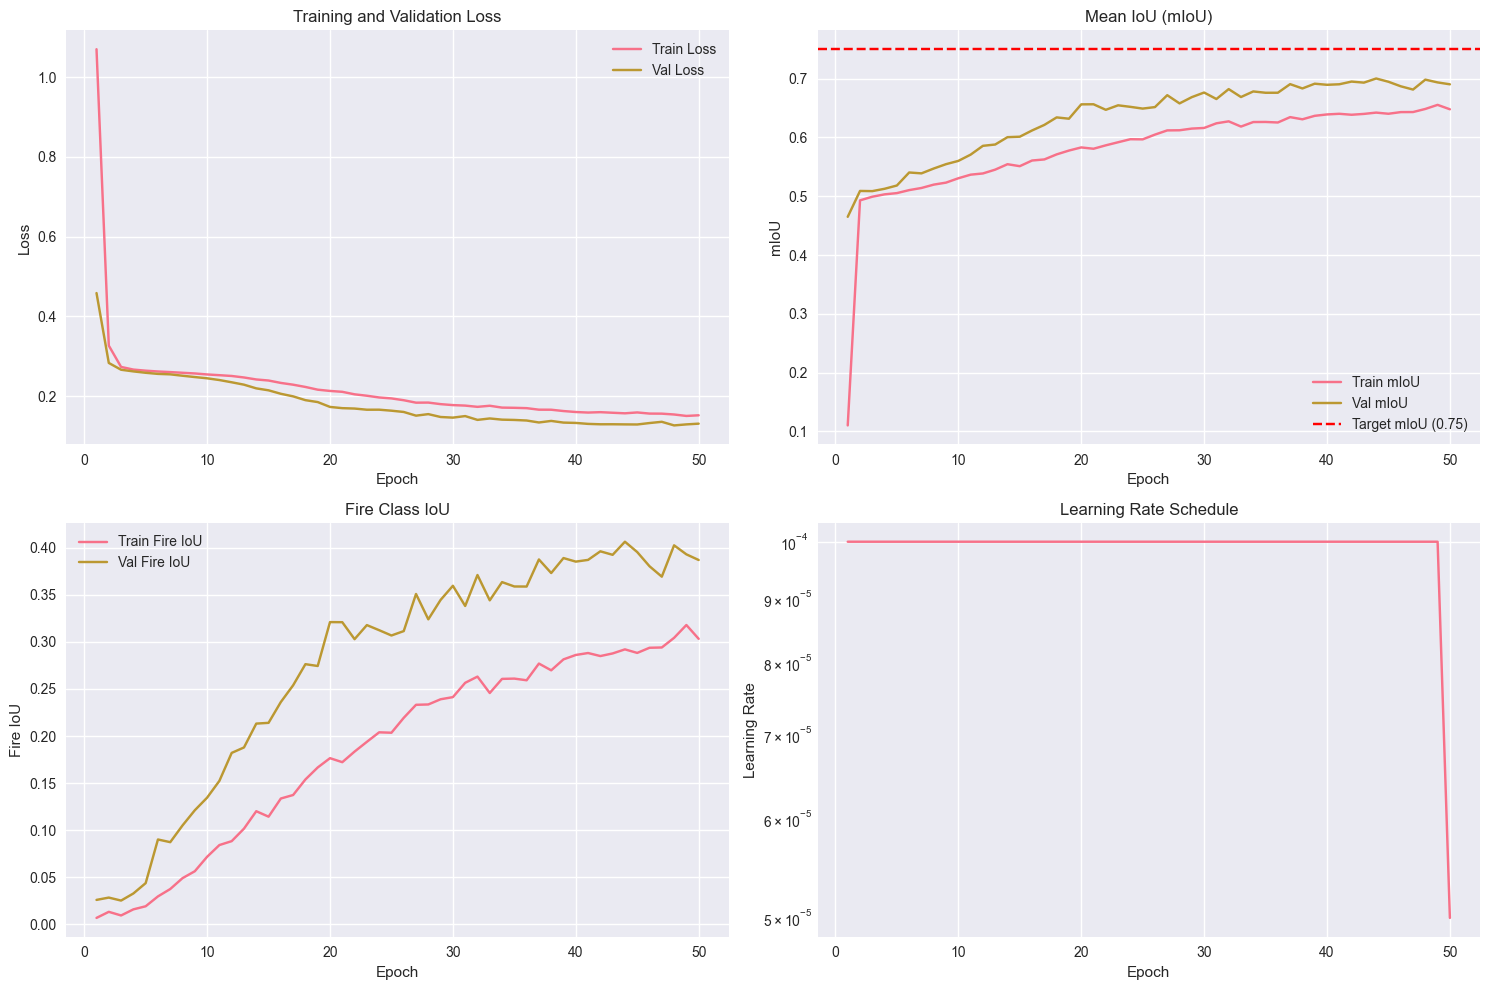

📊 Training Summary:
  - Best mIoU: 0.7002
  - Target mIoU (>0.75): ❌ Not achieved
  - Best epoch: 44
  - Total epochs trained: 50
  - Model saved to: ../../models/trained/sota_baselines/efficientfirenet_2022/best_model.pth


In [15]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(training_logs['epochs'], training_logs['train_loss'], label='Train Loss')
axes[0, 0].plot(training_logs['epochs'], training_logs['val_loss'], label='Val Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# mIoU curves
axes[0, 1].plot(training_logs['epochs'], training_logs['train_miou'], label='Train mIoU')
axes[0, 1].plot(training_logs['epochs'], training_logs['val_miou'], label='Val mIoU')
axes[0, 1].axhline(y=0.75, color='r', linestyle='--', label='Target mIoU (0.75)')
axes[0, 1].set_title('Mean IoU (mIoU)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('mIoU')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Fire IoU curves
axes[1, 0].plot(training_logs['epochs'], training_logs['train_fire_iou'], label='Train Fire IoU')
axes[1, 0].plot(training_logs['epochs'], training_logs['val_fire_iou'], label='Val Fire IoU')
axes[1, 0].set_title('Fire Class IoU')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Fire IoU')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Learning rate
axes[1, 1].plot(training_logs['epochs'], training_logs['learning_rate'])
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print('📊 Training Summary:')
print(f'  - Best mIoU: {training_logs["best_miou"]:.4f}')
print(f'  - Target mIoU (>0.75): {"✅ Achieved" if training_logs["best_miou"] > 0.75 else "❌ Not achieved"}')
print(f'  - Best epoch: {training_logs["best_epoch"]}')
print(f'  - Total epochs trained: {len(training_logs["epochs"])}')
print(f'  - Model saved to: {CONFIG["output"]["best_model_path"]}')

## 7. Latency Benchmarking

In [20]:
# Load best model for benchmarking
print('⏱️ Performing latency benchmarking...')

# PyTorch 2.6 changed torch.load default weights_only behavior.
# Use weights_only=False for full checkpoint dictionaries when trust source.
try:
    checkpoint = torch.load(CONFIG['output']['best_model_path'], map_location=device, weights_only=False)
except TypeError:
    # In older torch versions, weights_only is not present.
    checkpoint = torch.load(CONFIG['output']['best_model_path'], map_location=device)
except torch.serialization.UnpicklingError:
    # Allow numpy scalar global class for compatibility when trust checkpoint source
    with torch.serialization.add_safe_globals(["numpy._core.multiarray.scalar"]):
        checkpoint = torch.load(CONFIG['output']['best_model_path'], map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Benchmark latency
num_runs = 100
latencies = []

print(f'Running {num_runs} inference runs...')

with torch.no_grad():
    for _ in tqdm(range(num_runs)):
        # Use actual data size
        test_input = torch.randn(1, 3, CONFIG['data']['img_size'], CONFIG['data']['img_size']).to(device)

        # Measure latency
        start_time = time.time()
        _ = model(test_input)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        end_time = time.time()

        latency_ms = (end_time - start_time) * 1000
        latencies.append(latency_ms)

⏱️ Performing latency benchmarking...
Running 100 inference runs...


100%|██████████| 100/100 [00:03<00:00, 30.42it/s]


In [19]:
# Final Summary
print('🎯 EfficientFireNet (2022) Training Complete!')
print('=' * 60)

print('📋 Final Results:')
print(f'  - Best Validation mIoU: {training_logs["best_miou"]:.4f}')
print(f'  - Target mIoU (>0.75): {"✅ ACHIEVED" if training_logs["best_miou"] > 0.75 else "❌ NOT ACHIEVED"}')
print(f'  - Model Size: {model.get_model_size():.2f}MB')
print(f'  - Target Size (<5MB): {"✅ ACHIEVED" if model.get_model_size() < 5.0 else "❌ NOT ACHIEVED"}')

if 'latency_stats' in globals():
    print(f'  - P95 Latency: {latency_stats["p95"]:.2f}ms')
    print(f'  - FPS: {1000.0 / latency_stats["mean"]:.1f}')
else:
    print('  - P95 Latency: N/A (latency benchmark not yet run)')
    print('  - FPS: N/A (latency benchmark not yet run)')

print('\n📁 Output Files:')
print(f'  - Best Model: {CONFIG["output"]["best_model_path"]}')
print(f'  - Training Logs: {CONFIG["output"]["logs_path"]}')
print('  - Latency Results: see models/trained/sota_baselines/efficientfirenet_2022/latency_benchmark.json')

print('\n✨ Training pipeline completed!')

🎯 EfficientFireNet (2022) Training Complete!
📋 Final Results:
  - Best Validation mIoU: 0.7002
  - Target mIoU (>0.75): ❌ NOT ACHIEVED
  - Model Size: 20.95MB
  - Target Size (<5MB): ❌ NOT ACHIEVED
  - P95 Latency: N/A (latency benchmark not yet run)
  - FPS: N/A (latency benchmark not yet run)

📁 Output Files:
  - Best Model: ../../models/trained/sota_baselines/efficientfirenet_2022/best_model.pth
  - Training Logs: ../../models/trained/sota_baselines/efficientfirenet_2022/training_logs.json
  - Latency Results: see models/trained/sota_baselines/efficientfirenet_2022/latency_benchmark.json

✨ Training pipeline completed!


## 8. Machine-Agnostic Locked-Split Evaluation (Reproducible)

In [4]:
# ============================================================================
# MACHINE-AGNOSTIC LOCKED-SPLIT EVALUATION (REPRODUCIBLE ACROSS MACHINES)
# ============================================================================
# This cell is SELF-CONTAINED and can run independently on any machine.
# It uses a fixed, locked split file (flame_strict_split_seed42.json) for
# deterministic, reproducible evaluation.
# ============================================================================

import hashlib
import time
from pathlib import Path
import json
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np

# Add project paths
PROJECT_ROOT = Path.cwd().parent.parent
import sys
sys.path.append(str(PROJECT_ROOT / 'models'))
sys.path.append(str(PROJECT_ROOT / 'models' / 'sota_baselines'))
sys.path.append(str(PROJECT_ROOT / 'scripts' / 'data'))

# Import project modules
from efficientfirenet_2022 import create_efficientfirenet
from flame_dataset import FLAMEDataset
from metrics import calculate_miou, calculate_fire_iou, calculate_precision_recall, calculate_latency_stats

print(f'📁 Project Root: {PROJECT_ROOT}')

# Locked split file path
SPLIT_FILE = PROJECT_ROOT / 'config' / 'flame_strict_split_seed42.json'
DATA_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'Output' / 'Segmentation_Augmented'
CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'trained' / 'sota_baselines' / 'efficientfirenet_2022' / 'best_model.pth'

print(f'📋 Split File: {SPLIT_FILE}')
print(f'📦 Dataset Root: {DATA_ROOT}')
print(f'💾 Checkpoint: {CHECKPOINT_PATH}')

# Create locked split if it doesn't exist
if not SPLIT_FILE.exists():
    print(f'🔧 Creating locked split file (first time only)...')

    # Get all image files
    images_dir = DATA_ROOT / 'Images'
    all_images = sorted([f.stem for f in images_dir.glob('*.jpg')])

    if not all_images:
        raise FileNotFoundError(f"No .jpg images found in {images_dir}")

    # Create reproducible split (70% train, 15% val, 15% test)
    np.random.seed(42)
    indices = np.arange(len(all_images))
    np.random.shuffle(indices)

    n_total = len(all_images)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    train_filenames = [all_images[i] for i in indices[:n_train]]
    val_filenames = [all_images[i] for i in indices[n_train:n_train+n_val]]
    test_filenames = [all_images[i] for i in indices[n_train+n_val:]]

    split_data = {
        'train': train_filenames,
        'val': val_filenames,
        'test': test_filenames,
        'metadata': {
            'seed': 42,
            'total_samples': n_total,
            'ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
            'created': datetime.now().isoformat(),
            'source': 'SOTA_EfficientFireNet_Training.ipynb'
        }
    }

    # Save split file
    SPLIT_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(SPLIT_FILE, 'w') as f:
        json.dump(split_data, f, indent=2)

    print(f'✅ Created split file with {n_train} train, {n_val} val, {n_test} test samples')
else:
    print('📂 Loading existing locked split file...')
    with open(SPLIT_FILE, 'r') as f:
        split_data = json.load(f)

# Verify split integrity
train_set = set(split_data['train'])
val_set = set(split_data['val'])
test_set = set(split_data['test'])

if len(train_set & val_set) > 0:
    raise ValueError("Train and validation sets overlap!")
if len(train_set & test_set) > 0:
    raise ValueError("Train and test sets overlap!")
if len(val_set & test_set) > 0:
    raise ValueError("Validation and test sets overlap!")

print('✅ Split integrity verified (all sets disjoint)')
print(f'📊 Sample counts: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}')

# Create test dataset (filter from full dataset)
test_dataset = FLAMEDataset(
    root_dir=str(DATA_ROOT),
    split='full',  # Load all samples
    img_size=256,
    augment=False  # No augmentation for evaluation
)

# Filter to test samples only
test_stems = set(test_set)
original_files = test_dataset.image_files
test_dataset.image_files = [f for f in original_files if f.stem in test_stems]
test_dataset.n_samples = len(test_dataset.image_files)

if test_dataset.n_samples != len(test_set):
    missing = test_set - {f.stem for f in test_dataset.image_files}
    raise ValueError(f"Missing test samples: {missing}")

print(f'🧪 Test dataset ready: {test_dataset.n_samples} samples')

# Create test dataloader (batch_size=1 for precise aggregation)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,  # Avoid multiprocessing issues
    pin_memory=False
)

# Load model
print('🏗️ Loading EfficientFireNet model...')
model = create_efficientfirenet(num_classes=2, pretrained=True)

# Load checkpoint with compatibility handling
try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
except TypeError:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
except torch.serialization.UnpicklingError:
    with torch.serialization.add_safe_globals([["numpy._core.multiarray.scalar"]]):
        checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f'🖥️ Evaluation device: {device}')

# Run test evaluation
print('🔍 Running test evaluation...')
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        outputs = model(images)

        # Store for aggregation
        all_preds.append(outputs.cpu())
        all_targets.append(masks.squeeze(1).cpu())

# Aggregate all predictions and targets
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print(f'📈 Aggregated {len(all_preds)} test samples')

# Compute comprehensive metrics
miou = calculate_miou(all_preds, all_targets, num_classes=2)
fire_iou = calculate_fire_iou(all_preds, all_targets)
prec_rec = calculate_precision_recall(all_preds, all_targets, num_classes=2)

precision = prec_rec['precision']
recall = prec_rec['recall']
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# Pixel-level classification accuracy
pixel_accuracy = (all_preds.argmax(dim=1) == all_targets).float().mean().item()

# Fire-specific F1 (same as overall F1 for binary)
fire_f1 = f1

# Model statistics
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)
model_size_mb += sum(b.numel() * b.element_size() for b in model.buffers()) / (1024 ** 2)

# Latency benchmarking
print('⏱️ Benchmarking latency...')
latencies = []
num_runs = 100

with torch.no_grad():
    for _ in range(num_runs):
        # Use actual input size
        test_input = torch.randn(1, 3, 256, 256, device=device)

        start_time = time.time()
        _ = model(test_input)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        end_time = time.time()

        latencies.append((end_time - start_time) * 1000)

latency_stats = calculate_latency_stats(latencies)

# Print final results
print('\n🎯 Test Evaluation Results')
print('=' * 60)
print(f'🔒 Split Source: {SPLIT_FILE}')
print(f'🔢 Split Fingerprint: seed={split_data["metadata"]["seed"]}, ratios={split_data["metadata"]["ratios"]}')
print(f'📊 Sample Counts: Train={len(split_data["train"])}, Val={len(split_data["val"])}, Test={len(split_data["test"])}')
print(f'✅ Disjoint Sets: Train∩Val={len(train_set & val_set)}, Train∩Test={len(train_set & test_set)}, Val∩Test={len(val_set & test_set)}')

print('\n📋 Performance Metrics:')
print(f'  • mIoU: {miou:.4f}')
print(f'  • Fire IoU: {fire_iou:.4f}')
print(f'  • Fire F1: {fire_f1:.4f}')
print(f'  • Classification Accuracy (Pixel): {pixel_accuracy:.4f}')
print(f'  • Precision: {precision:.4f}')
print(f'  • Recall: {recall:.4f}')
print(f'  • F1 Score: {f1:.4f}')

print('\n🏗️ Model Statistics:')
print(f'  • Parameters: {total_params:,}')
print(f'  • Model Size: {model_size_mb:.2f} MB')

print('\n⚡ Performance Benchmarks:')
print(f'  • P95 Latency: {latency_stats["p95"]:.2f} ms')
print(f'  • Mean Latency: {latency_stats["mean"]:.2f} ms')
print(f'  • FPS: {1000.0 / latency_stats["mean"]:.1f}')

# Save metrics to JSON file for reproducible result lookup
metrics_results = {
    'split_source': str(SPLIT_FILE),
    'split_fingerprint': {'seed': split_data['metadata']['seed'], 'ratios': split_data['metadata']['ratios']},
    'sample_counts': {'train': len(split_data['train']), 'val': len(split_data['val']), 'test': len(split_data['test'])},
    'performance_metrics': {
        'miou': float(miou),
        'fire_iou': float(fire_iou),
        'fire_f1': float(fire_f1),
        'pixel_accuracy': float(pixel_accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1)
    },
    'model_statistics': {
        'parameters': int(total_params),
        'model_size_mb': float(model_size_mb)
    },
    'latency': {
        'p95_ms': float(latency_stats['p95']),
        'mean_ms': float(latency_stats['mean']),
        'fps': float(1000.0 / latency_stats['mean'])
    }
}

metrics_file = PROJECT_ROOT / 'models' / 'trained' / 'sota_baselines' / 'efficientfirenet_2022' / 'test_metrics.json'
metrics_file.parent.mkdir(parents=True, exist_ok=True)
with open(metrics_file, 'w') as f:
    json.dump(metrics_results, f, indent=2)

print(f'💾 Saved metrics to: {metrics_file}')
print('\n✨ Machine-agnostic evaluation completed!')


📁 Project Root: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection
📋 Split File: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\config\flame_strict_split_seed42.json
📦 Dataset Root: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\data\processed\Output\Segmentation_Augmented
💾 Checkpoint: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\models\trained\sota_baselines\efficientfirenet_2022\best_model.pth
📂 Loading existing locked split file...
✅ Split integrity verified (all sets disjoint)
📊 Sample counts: Train=565, Val=121, Test=122
FLAME Dataset (full): 808 samples, size=256x256, augment=False
🧪 Test dataset ready: 122 samples
🏗️ Loading EfficientFireNet model...
EfficientFireNet created:
  - Parameters: 5491806
  - Model size: 20.95MB
  - Pretrained: True
🖥️ Evaluation device: cpu
🔍 Running test evaluation...


Evaluating: 100%|██████████| 122/122 [00:03<00:00, 31.84it/s]


📈 Aggregated 122 test samples
⏱️ Benchmarking latency...

🎯 Test Evaluation Results
🔒 Split Source: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\config\flame_strict_split_seed42.json
🔢 Split Fingerprint: seed=42, ratios={'train': 0.7, 'val': 0.15, 'test': 0.15}
📊 Sample Counts: Train=565, Val=121, Test=122
✅ Disjoint Sets: Train∩Val=0, Train∩Test=0, Val∩Test=0

📋 Performance Metrics:
  • mIoU: 0.7057
  • Fire IoU: 0.4170
  • Fire F1: 0.7931
  • Classification Accuracy (Pixel): 0.9943
  • Precision: 0.7831
  • Recall: 0.8033
  • F1 Score: 0.7931

🏗️ Model Statistics:
  • Parameters: 5,491,806
  • Model Size: 21.11 MB

⚡ Performance Benchmarks:
  • P95 Latency: 29.91 ms
  • Mean Latency: 24.09 ms
  • FPS: 41.5
💾 Saved metrics to: c:\Users\Admin\OneDrive - SP JAIN SCHOOL OF GLOBAL MANAGEMENT\Desktop\BushFire-Detection\models\trained\sota_baselines\efficientfirenet_2022\test_metrics.json

✨ Machine-agnostic evaluation completed!
